# Creating a Flood Inventory Map

## Overview

[Google Groundsource](https://zenodo.org/records/18647054) is a dataset of high-resolution flood observation derived from news articles. It contains data of flood events from 2000-2025 with precise dates extracted from the text and the corresponding geographic polygons derived from geocoding locations from Google Maps boundaries. The full dataset contains 2.6 million records and is available as a Parquet file. This notebook demonstrates how to use GeoPandas to efficiently load, filter, and analyze this large Parquet dataset to aggregate this records over a regular grid and create a flood inventory for your chosen country.

**Input Layers**:
* `groundsource_2026.parquet`: Google Groundsource flood observations dataset (Parquet format)
* `ne_10m_admin_0_countries_ind.zip`: Natural Earth Admin0 country boundaries shapefile

**Output**:
* `flood_inventory_grid.gpkg`: A GeoPackage with a layer of 10km x 10km grid cells with flood event counts.

**Data Credit**

* Mayo, R., Zlydenko, O., Bootbool, M., Fronman, S., Gilon, O., Hassidim, A., Kratzert, F., Loike, G., Matias, Y., Nakar, Y., Nearing, G., Sayag, R., Sicherman, A., Zemach, I., & Cohen, D. (2026). Groundsource: A Dataset of Flood Events from News https://doi.org/10.5281/zenodo.18647054
* Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.


**Watch Video Walkthrough**: Watch a detailed explanation of the workflow. <a href='https://www.youtube.com/watch?v=lJHKkLKbWoQ' target='_blank'><i class='fab fa-youtube' style='color: red; font-size: 1.5em;'></i> YouTube</a>

**Running the Notebook**:  
The preferred way to run this notebook is on Google Colab.  <a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/geopandas_flood_frequency.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Note: This tutorial was earlier named *Creating a Flood Frequency Map* but we have renamed it based on feedback from the community.

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [1]:
import os
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.wkb
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from shapely import STRtree

In [2]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [3]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url).split('?')[0])
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    return filename

shapefile = 'ne_10m_admin_0_countries_ind.zip'
shapefile_url = f'https://naciscdn.org/naturalearth/10m/cultural/{shapefile}'

parquet_file = 'groundsource_2026.parquet'
parquet_url = f'https://zenodo.org/records/18647054/files/{parquet_file}?download=1'

download(shapefile_url)
download(parquet_url)

Downloaded data/ne_10m_admin_0_countries_ind.zip
Downloaded data/groundsource_2026.parquet


'data/groundsource_2026.parquet'

## Creating a Grid

Load the Natural Earth Admin0 boundaries and extract the polygon. Here we select India using the 3-digit ISO code.

In [4]:
shapefile_path = os.path.join(data_folder, shapefile)
gdf = gpd.read_file(shapefile_path, encoding='utf-8')
country = gdf[gdf['SOV_A3'] == 'IND']
country.iloc[:, :5]

,ADM0_A3_IN,featurecla,scalerank,LABELRANK,SOVEREIGNT
8,IND,Admin-0 country,0,2,India


Create a regular grid over the bounding box of the country, then use a spatial join to keep only cells that intersect the country boundary.

Here we are using `EPSG:7755` which is a LCC projection suitable for India. For other countries use an appropriate projected CRS. If you are not sure `EPSG:3857` (Web Mercator) is a decent choice for most use cases.

In [5]:
grid_size = 10000  # 10 km in metres
grid_crs = 'EPSG:7755' # India LCC

In [6]:
from shapely.geometry import box

cell_size = grid_size

country_proj = country.to_crs(grid_crs)
minx, miny, maxx, maxy = country_proj.total_bounds

xs = np.arange(minx, maxx, cell_size)
ys = np.arange(miny, maxy, cell_size)

polygons = [
    box(x, y, x + cell_size, y + cell_size)
    for x in xs
    for y in ys
]

grid = gpd.GeoDataFrame({'geometry': polygons}, crs=grid_crs)

# Keep only cells that intersect the country — faster than clip as it avoids
# computing exact geometric intersections along the boundary
grid_country = gpd.sjoin(grid, country_proj[['geometry']],
                         how='inner', predicate='intersects')
grid_country = grid_country.drop(columns=['index_right']).reset_index(drop=True)
print(f'Cells intersecting the country: {len(grid_country):,}')

Cells intersecting the country: 32,970


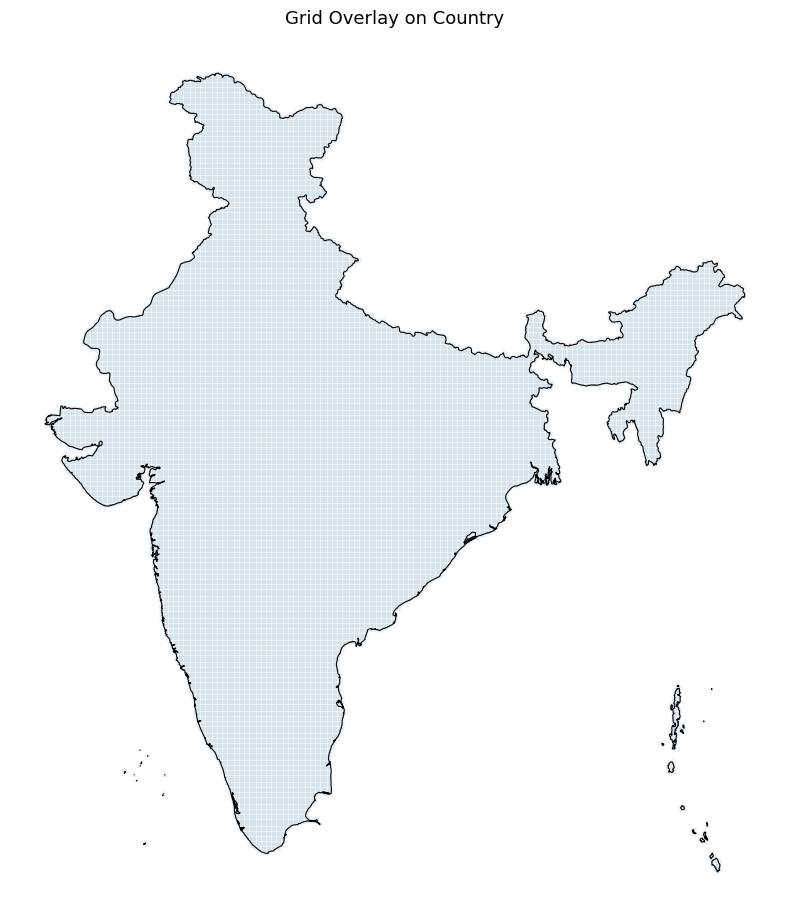

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
grid_country.plot(ax=ax, facecolor='none', edgecolor='steelblue',
                  linewidth=0.1, alpha=0.8)
country_proj.plot(ax=ax, facecolor='none', edgecolor='black',
                  linewidth=0.8)
ax.set_title('Grid Overlay on Country', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## Pre-Processing Flood Data

Read the parquet file of groundsource observations. GeoPandas supports reading GeoParquet files directly using the [`read_parquet()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.read_parquet.html) function.

In [8]:
parquet_file_path = os.path.join(data_folder, parquet_file)
gdf = gpd.read_parquet(parquet_file_path)
gdf.head()

,uuid,area_km2,geometry,start_date,end_date
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,"MULTIPOLYGON (((8.64252 53.60898, 8.65179 53.6...",2000-01-01,2000-01-01
1,f80fccbefb1346a9b568907086e65226,609.968365,"MULTIPOLYGON (((-0.01457 51.65825, -0.00151 51...",2000-01-01,2000-01-01
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,"POLYGON ((-58.43034 -34.61363, -58.42461 -34.6...",2000-01-24,2000-01-24
3,ce7f01a29de040b39e138f198fc39d86,0.548906,"POLYGON ((23.44227 47.63646, 23.43369 47.6408,...",2000-01-30,2000-01-30
4,eb047dfea9ed406485010853226e0170,0.236562,"POLYGON ((-57.54008 -38.00748, -57.5575 -38.02...",2000-01-30,2000-01-30


We filter the data to the bounds of the chosen country. We use the [`cx`](https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoDataFrame.cx.html) indexer to select the matching polygons within the bounding box. This is orders of magnitude faster than using `.clip()`.

In [9]:
geometry = country.geometry.union_all()
xmin, ymin, xmax, ymax = geometry.bounds
gdf_filtered= gdf.cx[xmin:xmax, ymin:ymax]
print('Total records within the country bounding box:', len(gdf_filtered))

Total records within the country bounding box: 445244


## Duplicate Flood Event Detection

One of the problems with aggregating this dataset over a grid is the presense of overlapping polygons for the same flood event. While Google did perform some spatio-temporal aggregation, the dataset still has overlapping records from the same flood event that have different geographic extent and slightly varying dates (an article may talk about flooding in the city while another will talk about the same flood in a neighborhood). Our goal is to count the total unique flood events aggregated for each grid and we want to only count unique flood events. We apply a pre-processing step to find all pairs of spatially intersecting polygons with `start_date` values within a few days of each other and assign the the same `flood_event` id.

In [10]:
# This step is computationally intensive and takes a few minutes.

# Work on a clean positional index
gdf_flood = gdf_filtered.reset_index(drop=True)
dates = pd.to_datetime(gdf_flood['start_date']).values
ndays = 7

# Use spatial index to find candidate pairs
tree = STRtree(gdf_flood.geometry.values)
left_idx, right_idx = tree.query(gdf_flood.geometry.values, predicate='intersects')

# Filter out self-intersections and redundant pairs (a,b vs b,a)
mask = left_idx < right_idx
left_idx = left_idx[mask]
right_idx = right_idx[mask]

# Compute date differences using NumPy to avoid creating a large DataFrame
# If you run out of memory at this step, you can do this in chunks
date_diff_days = np.abs(
    (dates[left_idx] - dates[right_idx]).astype('timedelta64[D]').astype(int)
)

# Filter indices based on the date threshold
time_mask = date_diff_days <= ndays
nearby_left = left_idx[time_mask]
nearby_right = right_idx[time_mask]

# Now create a 'nearby' dataframe only for valid pairs
nearby = pd.DataFrame({
    'idx_a': nearby_left,
    'idx_b': nearby_right
})

# Now use connected_components to assign a shared `flood_event` id to groups
# of intersecting temporally-close polygons
n = len(gdf_flood)

# Build a symmetric sparse adjacency matrix from the nearby pairs
row = np.concatenate([nearby['idx_a'].values, nearby['idx_b'].values])
col = np.concatenate([nearby['idx_b'].values, nearby['idx_a'].values])
graph = coo_matrix((np.ones(len(row), dtype=np.int8), (row, col)), shape=(n, n))

n_components, labels = connected_components(graph, directed=False)

print(f'Total polygons:           {n:>10,}')
print(f'Unique flood events:      {n_components:>10,}')
print(f'Avg polygons per event:   {n / n_components:>10.2f}')

Total polygons:              445,244
Unique flood events:         154,446
Avg polygons per event:         2.88


Add the labels to the main GeoDataFrame.

In [11]:
gdf_flood['flood_event'] = labels
gdf_flood[['uuid', 'start_date', 'end_date', 'flood_event']]

,uuid,start_date,end_date,flood_event
0,0525451f20a74d7d8f2ddfc4745023fa,2000-06-11,2000-06-11,0
1,0ec6b2470e184e008386f3fa69cff028,2000-06-11,2000-06-11,1
2,d274bd96994a45e4b1260c873c37f68a,2000-08-23,2000-08-25,2
3,f12e4bf730f441c5be7fb6f513fbf37c,2000-08-23,2000-08-24,2
4,ec0423869205457e83d2a8a1bddf3b8f,2000-08-23,2000-08-24,3
...,...,...,...,...
445239,e22350a6937548f4a6ee79b6f5f2c1c6,2026-01-27,2026-01-28,154442
445240,d35c1d49e7984ce5af13d1f143d2e44b,2026-01-27,2026-01-28,154433
445241,d865e504914b4c5db36857b51e7f8f95,2026-01-28,2026-01-28,154443
445242,5227559c88944c9c8ede1aa41d4a4431,2026-01-28,2026-01-28,154444


## Aggregate Flood Events to Grid

We now count the number of unique flood events per grid cell.

Reproject the filtered flood points to the chosen CRS.

In [12]:
gf_reprojected = gdf_flood.to_crs(grid_crs)

Do a Spatial Join of flood polygons to grid cells using `gpd.sjoin()`. We use `inner` join so we get 1 record for each intersection of a grid with a flood polygon.

In [13]:
joined = gpd.sjoin(grid_country, gf_reprojected,
                   how='inner', predicate='intersects')

Count the unique number of `flood_events` in each cell using with `groupby()` followed by `nunique()`.

In [14]:
counts = joined.groupby(joined.index)['flood_event'].nunique().rename('flood_count')

grid_country['flood_count'] = grid_country.index.map(counts).fillna(0).astype(int)
grid_country.head()

,geometry,flood_count
0,"POLYGON ((2824915.114 3996846.6, 2824915.114 4...",0
1,"POLYGON ((2824915.114 4006846.6, 2824915.114 4...",0
2,"POLYGON ((2824915.114 4016846.6, 2824915.114 4...",1
3,"POLYGON ((2824915.114 4026846.6, 2824915.114 4...",1
4,"POLYGON ((2834915.114 3996846.6, 2834915.114 4...",0


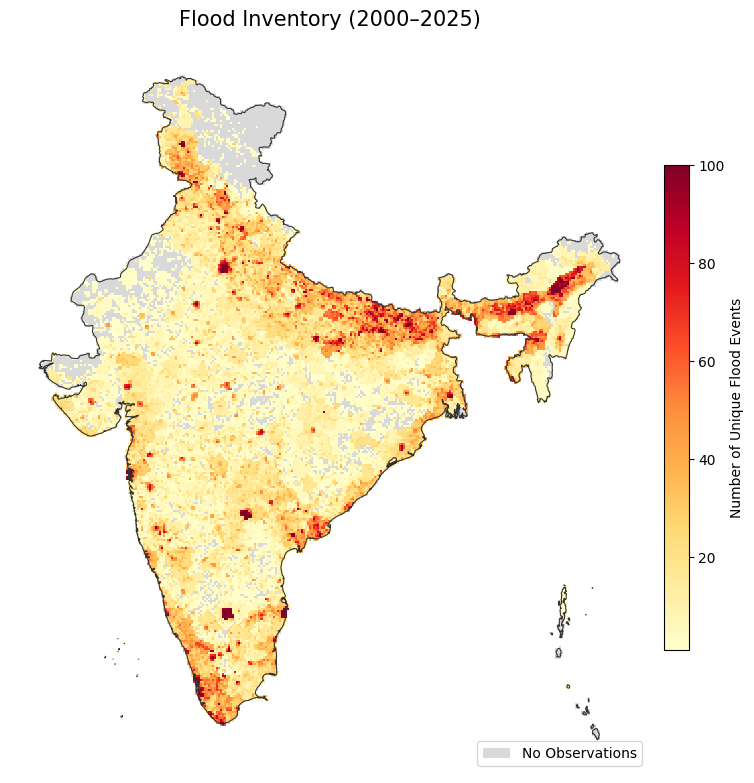

In [15]:
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 10))

# Cells with no observations in neutral grey
grid_country[grid_country['flood_count'] == 0].plot(
    ax=ax, color='#d9d9d9', linewidth=0
)

# Cells with observations coloured by flood count
# Using simple linear scale from 1 to 100
cmap = 'YlOrRd'

non_zero = grid_country[grid_country['flood_count'] > 0]
non_zero.plot(
    ax=ax, column='flood_count',
    cmap=cmap, vmin=1, vmax=100, linewidth=0
)

# Add Colorbar (Legend for flood counts)
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=100))
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Number of Unique Flood Events', fontsize=10)

# Add manual legend for the 'No Data' category
legend_elements = [Patch(facecolor='#d9d9d9', label='No Observations')]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

# Country boundary
country_proj.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=0.8)

ax.set_title('Flood Inventory (2000–2025)', fontsize=15, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

Save the results to a GeoPackage.

In [16]:
output_filename = 'flood_inventory_grid.gpkg'
output_filepath = os.path.join(output_folder, output_filename)
grid_country.to_file(output_filepath)